In [6]:
import os
import numpy as np
import scipy.io as sio
from sklearn.model_selection import train_test_split

# folders
AD_FOLDER = "AD"
HC_FOLDER = "HC"


def load_subject(file_path):

    mat = sio.loadmat(file_path)

    data = mat["data"]

    trials_cell = data["trial"][0,0]

    subject_trials = []

    for t in range(len(trials_cell[0])):

        trial = trials_cell[0][t]   # correct extraction

        trial = np.array(trial)

        # ensure correct shape
        if trial.ndim == 2:
            trial = trial[:16, :]   # keep 16 channels
            subject_trials.append(trial)

    return np.array(subject_trials)


subjects = []
labels = []

# AD subjects
for f in sorted(os.listdir(AD_FOLDER)):
    if f.endswith(".mat"):
        subject_data = load_subject(os.path.join(AD_FOLDER,f))
        subjects.append(subject_data)
        labels.append(1)   # AD = 1

# HC subjects
for f in sorted(os.listdir(HC_FOLDER)):
    if f.endswith(".mat"):
        subject_data = load_subject(os.path.join(HC_FOLDER,f))
        subjects.append(subject_data)
        labels.append(0)   # HC = 0

subjects = np.array(subjects, dtype=object)
labels = np.array(labels)

print("Total subjects:", len(subjects))

Total subjects: 23


In [7]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import accuracy_score
import copy
import matplotlib.pyplot as plt

In [8]:
train_idx, test_idx = train_test_split(
    np.arange(len(subjects)),
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_subjects = subjects[train_idx]
test_subjects = subjects[test_idx]

train_labels = labels[train_idx]
test_labels = labels[test_idx]

Train shape: (553, 20480)
Test shape: (110, 20480)
Epoch 1/100, Loss: 0.3780, Train Acc: 0.8716, Val Acc: 0.5727
Epoch 2/100, Loss: 0.2344, Train Acc: 0.9494, Val Acc: 0.6182
Epoch 3/100, Loss: 0.1827, Train Acc: 0.9765, Val Acc: 0.5727
Epoch 4/100, Loss: 0.1678, Train Acc: 0.9693, Val Acc: 0.5091
Epoch 5/100, Loss: 0.1546, Train Acc: 0.9783, Val Acc: 0.5455
Epoch 6/100, Loss: 0.1166, Train Acc: 0.9873, Val Acc: 0.6091
Epoch 7/100, Loss: 0.1085, Train Acc: 0.9855, Val Acc: 0.6273
Epoch 8/100, Loss: 0.0941, Train Acc: 0.9855, Val Acc: 0.6455
Epoch 9/100, Loss: 0.1044, Train Acc: 0.9855, Val Acc: 0.6364
Epoch 10/100, Loss: 0.0918, Train Acc: 0.9892, Val Acc: 0.6364
Epoch 11/100, Loss: 0.0915, Train Acc: 0.9892, Val Acc: 0.6091
Epoch 12/100, Loss: 0.0977, Train Acc: 0.9837, Val Acc: 0.5909
Epoch 13/100, Loss: 0.0689, Train Acc: 0.9946, Val Acc: 0.6000
Epoch 14/100, Loss: 0.0731, Train Acc: 0.9892, Val Acc: 0.5455
Epoch 00014: reducing learning rate of group 0 to 4.5000e-05.
Epoch 15/100, 

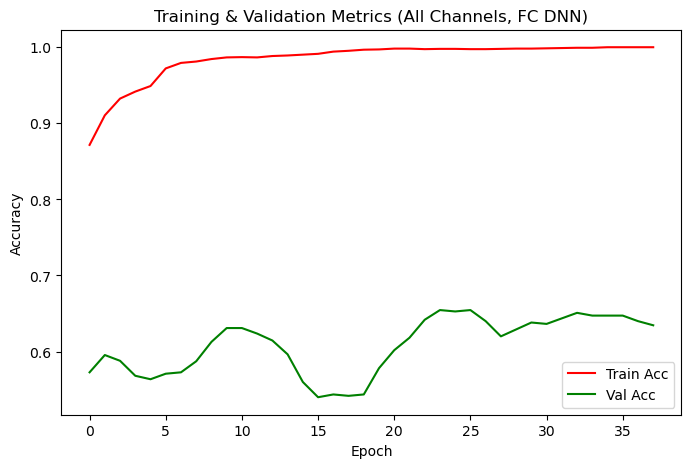

In [10]:
# ---------------------------
# Build dataset using all channels
# ---------------------------
def build_trial_dataset_all_channels(subjects, labels):
    X = []
    y = []

    for i, subject in enumerate(subjects):
        trials = subject
        for t in trials:
            X.append(t.flatten())  # use all channels
            y.append(labels[i])

    return np.array(X), np.array(y)  # X shape: (num_trials, channels * timepoints)

# Build training and testing datasets
X_train, y_train = build_trial_dataset_all_channels(train_subjects, train_labels)
X_test, y_test   = build_trial_dataset_all_channels(test_subjects, test_labels)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ---------------------------
# Normalize each trial independently
# ---------------------------
def normalize_trials(X):
    return (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-6)

X_train = normalize_trials(X_train)
X_test  = normalize_trials(X_test)

# ---------------------------
# Optional: Downsample timepoints to reduce input size
# ---------------------------
downsample_factor = 4  
X_train = X_train[:, ::downsample_factor]
X_test  = X_test[:, ::downsample_factor]


# ---------------------------
# PyTorch Dataset
# ---------------------------
class EEGDatasetAllChannels(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = EEGDatasetAllChannels(X_train, y_train)
test_dataset  = EEGDatasetAllChannels(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16)

# ---------------------------
# DNN Model (Fully connected)
# ---------------------------
class EEG_DNN_FC(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.fc4 = nn.Linear(64, 2)
        self.dropout = nn.Dropout(0.1)  # stronger dropout
        self.act = nn.LeakyReLU(0.1)

    def forward(self, x):
        x = self.act(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.act(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.act(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = self.fc4(x)
        return x
input_size = X_train.shape[1]
model = EEG_DNN_FC(input_size)

# ---------------------------
# Training setup
# ---------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.00009, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)

# Early stopping
epochs = 100
patience = 15
best_acc = 0
best_model_wts = copy.deepcopy(model.state_dict())
no_improve_count = 0

train_losses, train_accuracies, val_accuracies = [], [], []

# ---------------------------
# Training loop
# ---------------------------
for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = total_loss / len(train_loader)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # Validation
    model.eval()
    val_preds, val_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            val_preds.extend(predicted.numpy())
            val_true.extend(y_batch.numpy())
    val_acc = accuracy_score(val_true, val_preds)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, Val Acc: {val_acc:.4f}")

    scheduler.step(val_acc)

    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        no_improve_count = 0
        torch.save(model.state_dict(), "best_eeg_model_fc.pth")
    else:
        no_improve_count += 1
        if no_improve_count >= patience:
            print(f"No improvement for {patience} epochs. Stopping early.")
            break

# Load best model
model.load_state_dict(best_model_wts)

# ---------------------------
# Plot smoothed curves
# ---------------------------
def smooth_curve(curve, window=5):
    smoothed = []
    for i in range(len(curve)):
        start = max(0, i-window+1)
        smoothed.append(np.mean(curve[start:i+1]))
    return smoothed

plt.figure(figsize=(8,5))
plt.plot(smooth_curve(train_accuracies), label="Train Acc", color='red')
plt.plot(smooth_curve(val_accuracies), label="Val Acc", color='green')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Metrics (All Channels, FC DNN)")
plt.legend()
plt.show()

In [ ]:
import copy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# ---------------------------
# Build trial-level dataset (leakage!)
# ---------------------------
def build_leaky_dataset(subjects, labels):
    X_all = []
    y_all = []
    for i, subject in enumerate(subjects):
        label = labels[i]
        for t in subject:
            X_all.append(t.flatten())  # use all channels
            y_all.append(label)
    return np.array(X_all), np.array(y_all)
# Combine all subjects for leakage demo
all_subjects = list(train_subjects) + list(test_subjects)
all_labels = list(train_labels) + list(test_labels)
X_all, y_all = build_leaky_dataset(all_subjects, all_labels)
# Combine all subjects for leakage demo
from sklearn.model_selection import train_test_split
X_train_leak, X_test_leak, y_train_leak, y_test_leak = train_test_split(
    X_all, y_all, test_size=0.2, shuffle=True)

# Normalize each trial independently
def normalize_trials(X):
    return (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-6)

X_train_leak = normalize_trials(X_train_leak)
X_test_leak  = normalize_trials(X_test_leak)

# ---------------------------
# PyTorch Dataset
# ---------------------------
class EEGDatasetAChannel(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = EEGDatasetAChannel(X_train_leak, y_train_leak)
test_dataset  = EEGDatasetAChannel(X_test_leak, y_test_leak)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16)

# ---------------------------
# DNN Model
# ---------------------------
class EEG_DNN_Channel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.fc4 = nn.Linear(32, 2)
        self.dropout = nn.Dropout(0.2)
        self.act = nn.LeakyReLU(0.1)

    def forward(self, x):
        x = self.act(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.act(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.act(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = self.fc4(x)
        return x

input_size = X_train_leak.shape[1]
model = EEG_DNN_Channel(input_size)

# ---------------------------
# Training setup
# ---------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)

epochs = 100
patience = 20
best_acc = 0
best_model_wts = copy.deepcopy(model.state_dict())
no_improve_count = 0

train_losses = []
train_accuracies = []
val_accuracies = []

# ---------------------------
# Training loop (leakage)
# ---------------------------
for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = total_loss / len(train_loader)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # Validation
    model.eval()
    val_preds, val_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            val_preds.extend(predicted.numpy())
            val_true.extend(y_batch.numpy())
    val_acc = accuracy_score(val_true, val_preds)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, Val Acc: {val_acc:.4f}")

    # Scheduler step
    scheduler.step(val_acc)

    # Early stopping & save best model
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        no_improve_count = 0
        torch.save(model.state_dict(), "best_eeg_model_leakage.pth")
    else:
        no_improve_count += 1
        if no_improve_count >= patience:
            print(f"No improvement for {patience} epochs. Stopping early.")
            break

# Load best weights
model.load_state_dict(best_model_wts)

# ---------------------------
# Plot smoothed training/validation curves
# ---------------------------
def smooth_curve(curve, window=5):
    smoothed = []
    for i in range(len(curve)):
        start = max(0, i-window+1)
        smoothed.append(np.mean(curve[start:i+1]))
    return smoothed

plt.figure(figsize=(8,5))
plt.plot(smooth_curve(train_accuracies), label="Train Acc", color='red')
plt.plot(smooth_curve(val_accuracies), label="Val Acc", color='green')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Metrics (With Leakage)")
plt.legend()
plt.show()

Epoch 1/100, Loss: 0.4706, Train Acc: 0.8019, Val Acc: 0.9173
Epoch 2/100, Loss: 0.3443, Train Acc: 0.8830, Val Acc: 0.9398
Epoch 3/100, Loss: 0.2679, Train Acc: 0.9000, Val Acc: 0.9699
Epoch 4/100, Loss: 0.2219, Train Acc: 0.9283, Val Acc: 0.9774
